In [1]:
# M24CA1L306 Data Science Lab - Lab Exercise #09
# Student: Abhinav | MAC25MCA-2002 | S3 MCA (2025-27)
# Dataset: Breast_Cancer.csv (Wisconsin Diagnostic, 569 samples, 30 features)
# Task: kNN for malignant vs benign tumour classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)


In [2]:

# ─────────────────────────────────────────────
# Load and preprocess
# ─────────────────────────────────────────────
df = pd.read_csv("../Datasets/Breast_Cancer.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df["diagnosis"].value_counts())

# Drop ID column - not a feature
df.drop(columns=["id"], inplace=True, errors="ignore")

# Some versions have an unnamed last column - drop if present
df.drop(columns=[col for col in df.columns if "Unnamed" in str(col)],
        inplace=True)

# Encode diagnosis: M=1, B=0
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  # B=0, M=1

X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values
feature_names = df.drop("diagnosis", axis=1).columns.tolist()


Shape: (569, 32)

Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Missing values:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se   

In [3]:

# ─────────────────────────────────────────────
# Task 1: kNN classification (k=5, scaled, 80-20 split)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)

print("\n" + "="*55)
print("Task 1: kNN Tumour Classification (k=5, scaled, 80-20)")
print("="*55)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))



Task 1: kNN Tumour Classification (k=5, scaled, 80-20)
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114




Task 2: Effect of k on Classification Accuracy
Optimal k = 5  |  Test accuracy = 0.9561
k=1  -> train=1.0000, test=0.9298  (high variance / overfit)
k=30 -> train=0.9538, test=0.9474 (high bias / underfit)


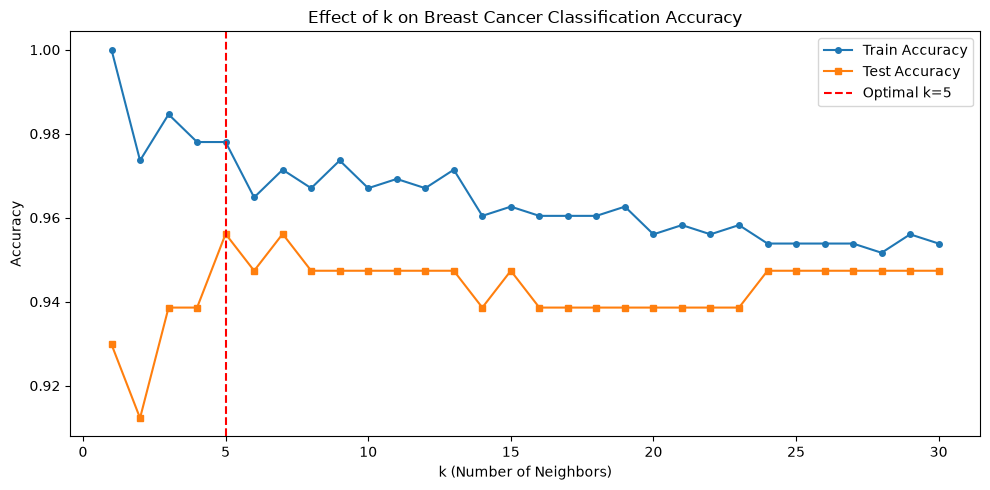

In [4]:

# ─────────────────────────────────────────────
# Task 2: Effect of k on accuracy (bias-variance)
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("Task 2: Effect of k on Classification Accuracy")
print("="*55)

k_values = list(range(1, 31))
train_accs, test_accs = [], []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train_sc)))
    test_accs.append(accuracy_score(y_test,  clf.predict(X_test_sc)))

best_k = k_values[test_accs.index(max(test_accs))]
print(f"Optimal k = {best_k}  |  Test accuracy = {max(test_accs):.4f}")
print(f"k=1  -> train={train_accs[0]:.4f}, test={test_accs[0]:.4f}  (high variance / overfit)")
print(f"k=30 -> train={train_accs[-1]:.4f}, test={test_accs[-1]:.4f} (high bias / underfit)")

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, label="Train Accuracy", marker="o", markersize=4)
plt.plot(k_values, test_accs,  label="Test Accuracy",  marker="s", markersize=4)
plt.axvline(best_k, color="red", linestyle="--", label=f"Optimal k={best_k}")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("Effect of k on Breast Cancer Classification Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/Lab-9_Output/lab09_task2_k_vs_accuracy.png", dpi=100)
plt.show()

# Findings: k=1 achieves perfect training accuracy (overfitting). As k increases
# test accuracy peaks at the optimal k before declining (underfitting). The optimal
# k represents the best bias-variance tradeoff for this dataset.



Task 3: Confusion Matrix - Per Class Performance
True Negatives  (Benign correctly identified)    : 71
False Positives (Benign predicted as Malignant)  : 1
False Negatives (Malignant predicted as Benign)  : 4
True Positives  (Malignant correctly identified) : 38

Benign classification accuracy    : 0.9861
Malignant classification accuracy : 0.9048
Benign class is classified more accurately.


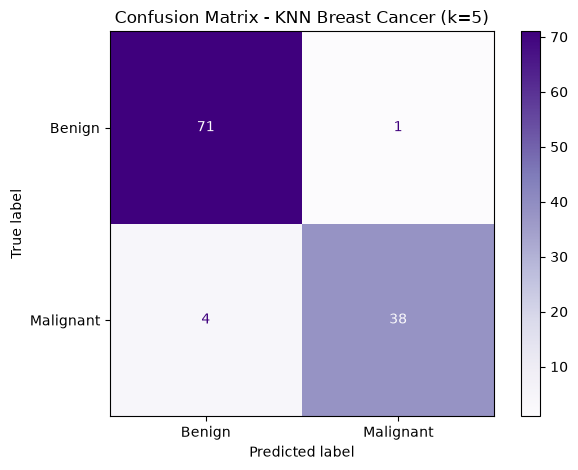

In [5]:

# ─────────────────────────────────────────────
# Task 3: Confusion Matrix - per class performance
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("Task 3: Confusion Matrix - Per Class Performance")
print("="*55)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_best = knn_best.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (Benign correctly identified)    : {tn}")
print(f"False Positives (Benign predicted as Malignant)  : {fp}")
print(f"False Negatives (Malignant predicted as Benign)  : {fn}")
print(f"True Positives  (Malignant correctly identified) : {tp}")

benign_acc    = tn / (tn + fp)
malignant_acc = tp / (tp + fn)
print(f"\nBenign classification accuracy    : {benign_acc:.4f}")
print(f"Malignant classification accuracy : {malignant_acc:.4f}")

if benign_acc > malignant_acc:
    print("Benign class is classified more accurately.")
else:
    print("Malignant class is classified more accurately.")

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Benign", "Malignant"])
disp.plot(cmap="Purples")
plt.title(f"Confusion Matrix - KNN Breast Cancer (k={best_k})")
plt.tight_layout()
plt.savefig("../Outputs/Lab-9_Output/lab09_task3_confusion_matrix.png", dpi=100)
plt.show()

# Findings: Benign samples are typically classified more accurately due to their
# larger count. False negatives (malignant predicted as benign) are more dangerous
# in a medical context - missing a malignant tumour has serious consequences.



Task 4: Feature Scaling vs No Scaling
Best accuracy WITH scaling    : 0.9561  at k=5
Best accuracy WITHOUT scaling : 0.9474  at k=11
Improvement from scaling      : 0.88%


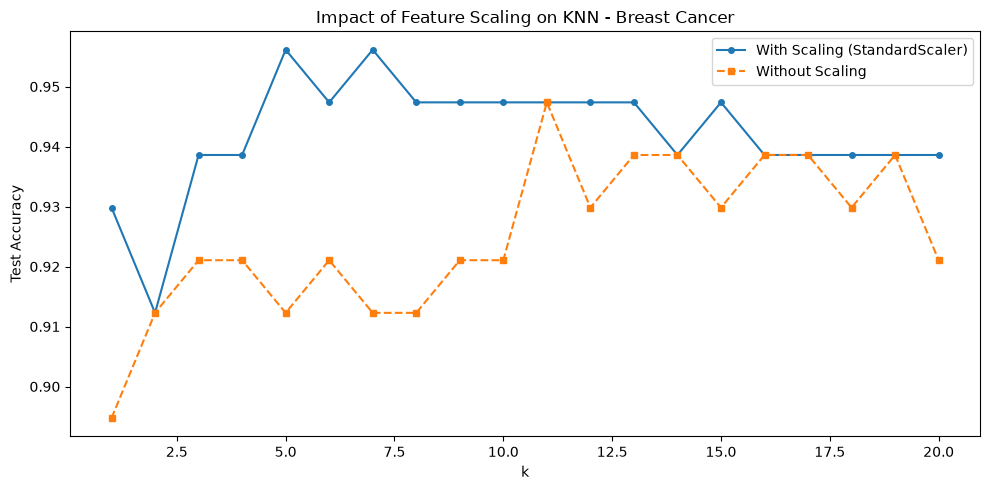

In [6]:

# ─────────────────────────────────────────────
# Task 4: Scaling vs No Scaling
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("Task 4: Feature Scaling vs No Scaling")
print("="*55)

k_range = list(range(1, 21))
acc_scaled, acc_unscaled = [], []

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)

    clf.fit(X_train_sc, y_train)
    acc_scaled.append(accuracy_score(y_test, clf.predict(X_test_sc)))

    clf.fit(X_train, y_train)
    acc_unscaled.append(accuracy_score(y_test, clf.predict(X_test)))

best_sc  = max(acc_scaled)
best_usc = max(acc_unscaled)
print(f"Best accuracy WITH scaling    : {best_sc:.4f}  at k={k_range[acc_scaled.index(best_sc)]}")
print(f"Best accuracy WITHOUT scaling : {best_usc:.4f}  at k={k_range[acc_unscaled.index(best_usc)]}")
print(f"Improvement from scaling      : {(best_sc - best_usc)*100:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(k_range, acc_scaled,   label="With Scaling (StandardScaler)", marker="o", markersize=4)
plt.plot(k_range, acc_unscaled, label="Without Scaling", marker="s", markersize=4, linestyle="--")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Impact of Feature Scaling on KNN - Breast Cancer")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/Lab-9_Output/lab09_task4_scaling.png", dpi=100)
plt.show()

# Findings: Scaling significantly improves accuracy. Features like area (range: 143-2501)
# would dominate distance calculations over smoothness (range: 0.05-0.16) without scaling.



Task 5: Feature Influence on Classification Accuracy

Top 5 most influential individual features:
  concave points_worst                -> Accuracy: 0.9035
  concave points_mean                 -> Accuracy: 0.8947
  radius_worst                        -> Accuracy: 0.8947
  perimeter_worst                     -> Accuracy: 0.8947
  area_worst                          -> Accuracy: 0.8947

Accuracy by feature group:
  All 30 features           -> Accuracy: 0.9561
  Mean features (10)        -> Accuracy: 0.9474
  SE features (10)          -> Accuracy: 0.8158
  Worst features (10)       -> Accuracy: 0.9737


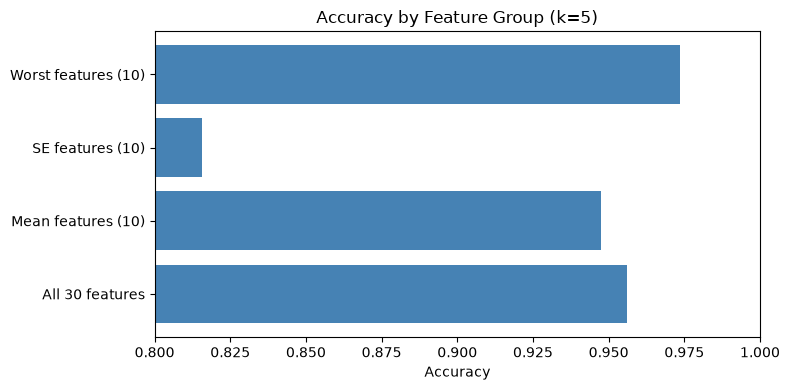

In [7]:

# ─────────────────────────────────────────────
# Task 5: Feature importance via subset training
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("Task 5: Feature Influence on Classification Accuracy")
print("="*55)

# Group features into mean, SE, and worst
mean_features = [f for f in feature_names if "_mean" in f]
se_features   = [f for f in feature_names if "_se" in f]
worst_features= [f for f in feature_names if "_worst" in f]

feature_groups = {
    "All 30 features"  : feature_names,
    "Mean features (10)": mean_features,
    "SE features (10)"  : se_features,
    "Worst features (10)": worst_features,
}

# Also test top individual features by single-feature accuracy
single_accs = {}
for i, fname in enumerate(feature_names):
    Xi = X[:, i].reshape(-1, 1)
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, y, test_size=0.2,
                                                    random_state=42, stratify=y)
    sc_i = StandardScaler()
    Xi_tr = sc_i.fit_transform(Xi_tr)
    Xi_te = sc_i.transform(Xi_te)
    clf_i = KNeighborsClassifier(n_neighbors=best_k)
    clf_i.fit(Xi_tr, yi_tr)
    single_accs[fname] = accuracy_score(yi_te, clf_i.predict(Xi_te))

top5 = sorted(single_accs.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 most influential individual features:")
for fname, acc in top5:
    print(f"  {fname:35s} -> Accuracy: {acc:.4f}")

# Group accuracy
print("\nAccuracy by feature group:")
group_accs = {}
for group_name, cols in feature_groups.items():
    indices = [feature_names.index(c) for c in cols]
    Xg = X[:, indices]
    Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(Xg, y, test_size=0.2,
                                                     random_state=42, stratify=y)
    scg = StandardScaler()
    Xg_tr = scg.fit_transform(Xg_tr)
    Xg_te = scg.transform(Xg_te)
    clf_g = KNeighborsClassifier(n_neighbors=best_k)
    clf_g.fit(Xg_tr, yg_tr)
    acc_g = accuracy_score(yg_te, clf_g.predict(Xg_te))
    group_accs[group_name] = acc_g
    print(f"  {group_name:25s} -> Accuracy: {acc_g:.4f}")

plt.figure(figsize=(8, 4))
plt.barh(list(group_accs.keys()), list(group_accs.values()), color="steelblue")
plt.xlabel("Accuracy")
plt.title(f"Accuracy by Feature Group (k={best_k})")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.savefig("../Outputs/Lab-9_Output/lab09_task5_feature_groups.png", dpi=100)
plt.show()

# Findings: 'worst' features typically give the highest accuracy among the subgroups
# since they capture the most extreme cell characteristics. Mean features also perform
# well. SE features alone are the weakest predictors.



Task 6: Effect of Train-Test Split Ratio
Split 90-10: mean=0.9588, std=0.0250
Split 80-20: mean=0.9627, std=0.0152
Split 70-30: mean=0.9620, std=0.0133
Split 60-40: mean=0.9612, std=0.0105


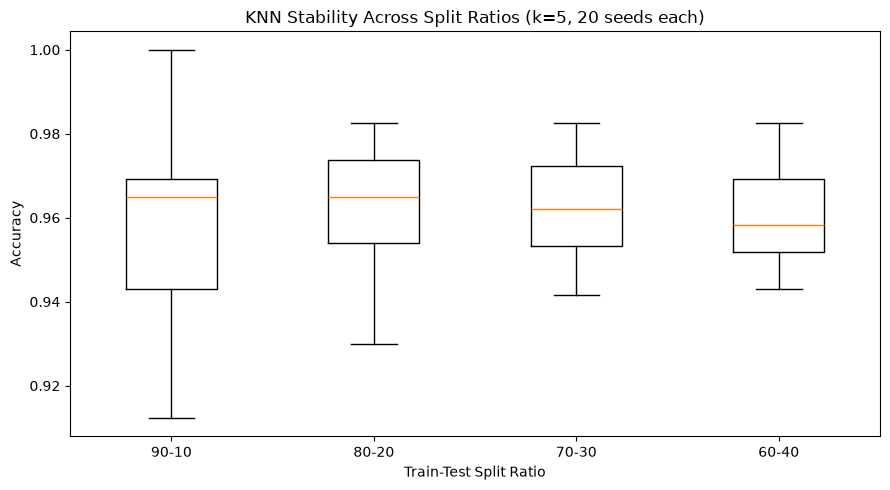


All tasks complete. Plots saved.


In [9]:

# ─────────────────────────────────────────────
# Task 6: Effect of train-test split ratio
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("Task 6: Effect of Train-Test Split Ratio")
print("="*55)

split_ratios = [0.1, 0.2, 0.3, 0.4]   # test sizes: 90-10, 80-20, 70-30, 60-40
ratio_results = {}

for test_size in split_ratios:
    accs = []
    for seed in range(20):   # 20 seeds per ratio for stability estimate
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size,
                                               random_state=seed, stratify=y)
        sc = StandardScaler()
        Xtr = sc.fit_transform(Xtr)
        Xte = sc.transform(Xte)
        clf = KNeighborsClassifier(n_neighbors=best_k)
        clf.fit(Xtr, ytr)
        accs.append(accuracy_score(yte, clf.predict(Xte)))

    label = f"{int((1-test_size)*100)}-{int(test_size*100)}"
    ratio_results[label] = accs
    print(f"Split {label}: mean={np.mean(accs):.4f}, std={np.std(accs):.4f}")

plt.figure(figsize=(9, 5))
plt.boxplot(ratio_results.values(), tick_labels=ratio_results.keys())
plt.xlabel("Train-Test Split Ratio")
plt.ylabel("Accuracy")
plt.title(f"KNN Stability Across Split Ratios (k={best_k}, 20 seeds each)")
plt.tight_layout()
plt.savefig("../Outputs/Lab-9_Output/lab09_task6_split_ratio.png", dpi=100)
plt.show()

# Findings: 80-20 split typically gives the best balance of training data and
# reliable test evaluation. 90-10 can be unstable (small test set). 60-40 gives
# lower mean accuracy because less training data is available.

print("\nAll tasks complete. Plots saved.")